Pobierz dane bazy plantvillage-dataset
Posługując się plikami 03_Regresja_logistyczna.ipynb, 04_Metody_ewaluacji.ipynb oraz przykładem klasyfikacji obrazowej na stronie logistic-regression-for-image-classification (lub jakimś innym tego typu) przeprowadź klasyfikację binarną na trzech wybranych parach klas liści.
W każdym przypadku podziel zbiór obrazów danej pary klas na zbiór treningowy i testowy.
Zastosuj walidację krzyżową.
Oceń jakość przez obliczenie: accuracy, recall, precision oraz F1
Całość obliczeń przedstaw w postaci notatnika jupyter

In [13]:
import os
import zipfile
import urllib.request

DATASET_DIR = 'plantvillage'
ZIP_PATH = os.path.expanduser('~/Downloads/plantvillage-dataset.zip')
URL = 'https://www.kaggle.com/api/v1/datasets/download/abdallahalidev/plantvillage-dataset'

if not os.path.exists(DATASET_DIR):
    # Pobierz dataset jeśli ZIP nie istnieje
    if not os.path.exists(ZIP_PATH):
        print('Pobieranie datasetu z Kaggle...')
        urllib.request.urlretrieve(URL, ZIP_PATH)
        print(f'Pobrano: {ZIP_PATH}')

    # Rozpakuj ZIP
    print('Rozpakowywanie...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('plantvillage-dataset')

    # Znajdź katalog z danymi i przenieś
    for root, dirs, files in os.walk('plantvillage-dataset'):
        for d in dirs:
            if 'plantvillage' in d.lower():
                os.rename(os.path.join(root, d), DATASET_DIR)
                print(f'Dane przeniesione do: {DATASET_DIR}')
                break
        if os.path.exists(DATASET_DIR):
            break

    if not os.path.exists(DATASET_DIR):
        print('UWAGA: Sprawdź strukturę pobranego archiwum')
        print('Zawartość:', os.listdir('plantvillage-dataset'))
else:
    print(f'Katalog {DATASET_DIR} już istnieje.')

Pobieranie datasetu z Kaggle...
Pobrano: /Users/szymon.pasieczny/Downloads/plantvillage-dataset.zip
Rozpakowywanie...
Dane przeniesione do: plantvillage


## 2. Przygotowanie danych

Dla każdej pary klas:
- Wczytaj obrazy i zmień rozmiar na 64×64
- Spłaszcz do wektora cech (flatten)
- Normalizuj wartości pikseli do zakresu [0, 1]
- Przypisz etykiety: klasa 1 (pozytywna) i klasa 0 (negatywna)
- Zrównoważ liczebność obu klas, aby uniknąć dominacji klasy większościowej
- Zachowaj proporcje klas podczas podziału na train/test i w walidacji krzyżowej (stratyfikacja)

In [14]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split

%matplotlib inline

IMG_SIZE = 64
RANDOM_STATE = 42
MAX_IMAGES_PER_CLASS = 500

def load_images(class_dir, label, max_images=500, random_state=42):
    """Wczytaj obrazy z katalogu, zmień rozmiar i spłaszcz."""
    images = []
    labels = []
    files = [
        fname for fname in sorted(os.listdir(class_dir))
        if os.path.isfile(os.path.join(class_dir, fname))
    ]
    rng = np.random.default_rng(random_state)
    if len(files) > max_images:
        files = sorted(rng.choice(files, size=max_images, replace=False))
    for fname in files:
        fpath = os.path.join(class_dir, fname)
        try:
            img = Image.open(fpath).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
            img_array = np.array(img).flatten() / 255.0
            images.append(img_array)
            labels.append(label)
        except Exception:
            continue
    return np.array(images), np.array(labels)

def balance_pair(X1, y1, X0, y0, random_state=42):
    """Wyrównaj liczebność klas, aby model nie faworyzował klasy większościowej."""
    limit = min(len(y1), len(y0))
    if limit == 0:
        raise ValueError('Jedna z klas nie zawiera poprawnie wczytanych obrazów.')
    rng = np.random.default_rng(random_state)
    idx1 = np.sort(rng.choice(len(y1), size=limit, replace=False))
    idx0 = np.sort(rng.choice(len(y0), size=limit, replace=False))
    return X1[idx1], y1[idx1], X0[idx0], y0[idx0]

def standardize_train_test(X_train, X_test):
    """Standaryzuj cechy na podstawie statystyk ze zbioru treningowego."""
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std < 1e-8] = 1.0
    return (X_train - mean) / std, (X_test - mean) / std

# Automatyczne wykrycie katalogu bazowego z klasami
BASE_DIR = DATASET_DIR
for candidate in ['color', 'segmented', 'grayscale']:
    test_path = os.path.join(DATASET_DIR, candidate)
    if os.path.isdir(test_path):
        BASE_DIR = test_path
        break

print(f'Katalog bazowy: {BASE_DIR}')
print(f'Dostępne klasy: {sorted(os.listdir(BASE_DIR))[:10]}...')
print(f'Rozmiar wektora cech: {IMG_SIZE}x{IMG_SIZE}x3 = {IMG_SIZE*IMG_SIZE*3}')

Katalog bazowy: plantvillage/color
Dostępne klasy: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']...
Rozmiar wektora cech: 64x64x3 = 12288


In [15]:
# Definicja trzech par klas (healthy vs disease)
pairs = [
    {
        'name': 'Pepper_bell: Healthy vs Bacterial_spot',
        'class_1': 'Pepper,_bell___healthy',
        'class_0': 'Pepper,_bell___Bacterial_spot',
    },
    {
        'name': 'Potato: Healthy vs Early_blight',
        'class_1': 'Potato___healthy',
        'class_0': 'Potato___Early_blight',
    },
    {
        'name': 'Tomato: Healthy vs Yellow_Leaf_Curl_Virus',
        'class_1': 'Tomato___healthy',
        'class_0': 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    },
]

# Weryfikacja istnienia katalogów
for pair in pairs:
    for key in ['class_1', 'class_0']:
        path = os.path.join(BASE_DIR, pair[key])
        status = 'OK' if os.path.isdir(path) else 'BRAK!'
        print(f'  {status}: {path}')

  OK: plantvillage/color/Pepper,_bell___healthy
  OK: plantvillage/color/Pepper,_bell___Bacterial_spot
  OK: plantvillage/color/Potato___healthy
  OK: plantvillage/color/Potato___Early_blight
  OK: plantvillage/color/Tomato___healthy
  OK: plantvillage/color/Tomato___Tomato_Yellow_Leaf_Curl_Virus


In [16]:
# Wczytanie danych dla każdej pary
datasets = {}

for pair in pairs:
    print(f"\nWczytywanie: {pair['name']}")
    dir_1 = os.path.join(BASE_DIR, pair['class_1'])
    dir_0 = os.path.join(BASE_DIR, pair['class_0'])
    
    X1_raw, y1_raw = load_images(dir_1, label=1, max_images=MAX_IMAGES_PER_CLASS,
                                 random_state=RANDOM_STATE)
    X0_raw, y0_raw = load_images(dir_0, label=0, max_images=MAX_IMAGES_PER_CLASS,
                                 random_state=RANDOM_STATE)
    X1, y1, X0, y0 = balance_pair(X1_raw, y1_raw, X0_raw, y0_raw,
                                 random_state=RANDOM_STATE)
    
    X_all = np.vstack((X1, X0))
    y_all = np.concatenate((y1, y0))
    
    # Losowe przemieszanie
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.permutation(len(y_all))
    X_all, y_all = X_all[idx], y_all[idx]
    
    datasets[pair['name']] = (X_all, y_all)
    print(f'  Oryginalnie -> klasa 1: {len(y1_raw)}, klasa 0: {len(y0_raw)}')
    print(f'  Po zbalansowaniu -> klasa 1: {len(y1)}, klasa 0: {len(y0)}')
    print(f'  Łącznie: {len(y_all)}, wymiar cech: {X_all.shape[1]}')


Wczytywanie: Pepper_bell: Healthy vs Bacterial_spot
  Klasa 1 (healthy): 500, Klasa 0 (disease): 500
  Łącznie: 1000, wymiar cech: 12288

Wczytywanie: Potato: Healthy vs Early_blight
  Klasa 1 (healthy): 152, Klasa 0 (disease): 500
  Łącznie: 652, wymiar cech: 12288

Wczytywanie: Tomato: Healthy vs Yellow_Leaf_Curl_Virus
  Klasa 1 (healthy): 500, Klasa 0 (disease): 500
  Łącznie: 1000, wymiar cech: 12288


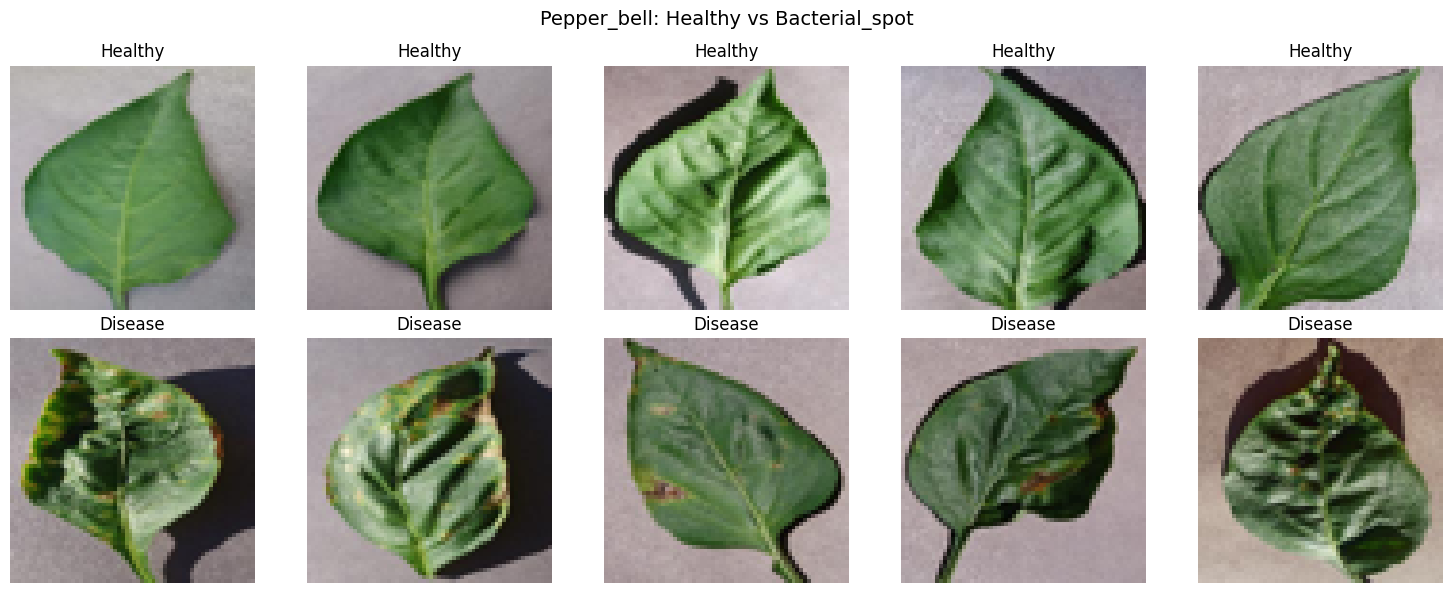

In [17]:
# Podgląd przykładowych obrazów z pierwszej pary
pair_name = list(datasets.keys())[0]
X_sample, y_sample = datasets[pair_name]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(pair_name, fontsize=14)

for row, (label, title) in enumerate([(1, 'Healthy'), (0, 'Disease')]):
    idxs = np.where(y_sample == label)[0][:5]
    for i, idx in enumerate(idxs):
        img = X_sample[idx].reshape(IMG_SIZE, IMG_SIZE, 3)
        axes[row, i].imshow(img)
        axes[row, i].set_title(title)
        axes[row, i].axis('off')

plt.tight_layout()
plt.show()

## 3. Implementacja regresji logistycznej

Funkcja hipotezy:
$$h_\theta(X) = g(X\theta) = \frac{1}{1 + e^{-X\theta}}$$

Funkcja kosztu:
$$J(\theta) = -\frac{1}{m}\left(\sum_{i=1}^{m} y^{(i)} \log h_\theta(x^{(i)}) + (1-y^{(i)}) \log(1-h_\theta(x^{(i)}))\right)$$

Gradient:
$$\nabla J(\theta) = \frac{1}{m} X^T (h_\theta(X) - \vec{y})$$

In [19]:
def sigmoid(z):
    """Funkcja sigmoidalna"""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def h(theta, X):
    """Funkcja hipotezy – regresja logistyczna"""
    return sigmoid(X @ theta)

def J(theta, X, y):
    """Funkcja kosztu dla regresji logistycznej"""
    m = len(y)
    h_val = np.clip(h(theta, X), 1e-7, 1 - 1e-7)
    return -1.0 / m * (y @ np.log(h_val) + (1 - y) @ np.log(1 - h_val))

def dJ(theta, X, y):
    """Gradient funkcji kosztu"""
    m = len(y)
    return 1.0 / m * (X.T @ (h(theta, X) - y))

def gradient_descent(theta, X, y, alpha=0.05, eps=1e-7, max_steps=1500):
    """Metoda gradientu prostego"""
    costs = [J(theta, X, y)]
    for step in range(max_steps):
        theta = theta - alpha * dJ(theta, X, y)
        current_cost = J(theta, X, y)
        if abs(costs[-1] - current_cost) <= eps:
            costs.append(current_cost)
            break
        costs.append(current_cost)
    return theta, costs

def predict(theta, X):
    """Predykcja klas"""
    return (h(theta, X) >= 0.5).astype(int)

print('Funkcje regresji logistycznej zdefiniowane.')

Funkcje regresji logistycznej zdefiniowane.


## 4. Metryki ewaluacji

- **Accuracy** = $\frac{TP + TN}{TP + TN + FP + FN}$
- **Precision** = $\frac{TP}{TP + FP}$
- **Recall** = $\frac{TP}{TP + FN}$
- **F1** = $\frac{2 \cdot \text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$

In [20]:
def compute_metrics(y_true, y_pred):
    """Oblicz TP, TN, FP, FN oraz accuracy, precision, recall, F1"""
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'F1': f1
    }

print('Metryki zdefiniowane.')

Metryki zdefiniowane.


## 5. Walidacja krzyżowa (5-fold)

Dane treningowe dzielimy na 5 części. Każda część naprzemiennie pełni rolę zbioru walidacyjnego, 
a pozostałe 4 służą do trenowania. Wyniki uśredniamy po wszystkich foldach.
Używamy walidacji stratyfikowanej, dzięki czemu każdy fold zachowuje proporcje klas.

In [21]:
def cross_validate(X, y, n_folds=5, alpha=0.05, max_steps=1500, random_state=42):
    """Stratyfikowana walidacja krzyżowa – zwraca metryki dla każdego folda i średnie."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    all_metrics = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_train = X[train_idx]
        y_train = y[train_idx]
        X_val = X[val_idx]
        y_val = y[val_idx]
        X_train_std, X_val_std = standardize_train_test(X_train, X_val)
        X_train_bias = np.column_stack((np.ones(len(X_train_std)), X_train_std))
        X_val_bias = np.column_stack((np.ones(len(X_val_std)), X_val_std))
        
        theta_start = np.zeros(X_train_bias.shape[1])
        theta, costs = gradient_descent(theta_start, X_train_bias, y_train,
                                        alpha=alpha, max_steps=max_steps)
        
        y_pred = predict(theta, X_val_bias)
        metrics = compute_metrics(y_val, y_pred)
        all_metrics.append(metrics)
        print(f'  Fold {fold}: accuracy={metrics["accuracy"]:.4f}, '
              f'precision={metrics["precision"]:.4f}, '
              f'recall={metrics["recall"]:.4f}, '
              f'F1={metrics["F1"]:.4f}')
    
    avg_metrics = {}
    for key in ['accuracy', 'precision', 'recall', 'F1']:
        avg_metrics[key] = np.mean([m[key] for m in all_metrics])
    
    return all_metrics, avg_metrics

print('Walidacja krzyżowa zdefiniowana.')

Walidacja krzyżowa zdefiniowana.


## 6. Klasyfikacja dla trzech par klas

Dla każdej pary:
1. Stratyfikowany podział na zbiór treningowy (80%) i testowy (20%)
2. Stratyfikowana walidacja krzyżowa (5-fold) na zbiorze treningowym
3. Trenowanie na pełnym zbiorze treningowym po standaryzacji cech
4. Ewaluacja na zbiorze testowym

In [22]:
results = {}

for pair_name, (X_all, y_all) in datasets.items():
    print(f'\n{"="*60}')
    print(f'PARA: {pair_name}')
    print(f'{"="*60}')
    
    # Stratyfikowany podział na zbiór treningowy (80%) i testowy (20%)
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
    )
    print(f'Zbiór treningowy: {len(y_train)}, testowy: {len(y_test)}')
    
    # Walidacja krzyżowa na zbiorze treningowym
    print(f'\nWalidacja krzyżowa (5-fold, stratyfikowana):')
    fold_metrics, avg_cv = cross_validate(X_train, y_train,
                                          n_folds=5, alpha=0.05, max_steps=1500,
                                          random_state=RANDOM_STATE)
    print(f'\n  Średnie CV: accuracy={avg_cv["accuracy"]:.4f}, '
          f'precision={avg_cv["precision"]:.4f}, '
          f'recall={avg_cv["recall"]:.4f}, '
          f'F1={avg_cv["F1"]:.4f}')
    
    # Trenowanie na pełnym zbiorze treningowym
    print(f'\nTrenowanie na pełnym zbiorze treningowym...')
    X_train_std, X_test_std = standardize_train_test(X_train, X_test)
    m_train = len(y_train)
    X_train_bias = np.column_stack((np.ones(m_train), X_train_std))
    theta_start = np.zeros(X_train_bias.shape[1])
    best_theta, costs = gradient_descent(theta_start, X_train_bias, y_train,
                                         alpha=0.05, max_steps=1500)
    print(f'  Koszt końcowy: {costs[-1]:.6f} (po {len(costs)} krokach)')
    
    # Ewaluacja na zbiorze testowym
    m_test = len(y_test)
    X_test_bias = np.column_stack((np.ones(m_test), X_test_std))
    y_pred = predict(best_theta, X_test_bias)
    test_metrics = compute_metrics(y_test, y_pred)
    
    print(f'\nWyniki na zbiorze testowym:')
    print(f'  TP={test_metrics["TP"]}, TN={test_metrics["TN"]}, '
          f'FP={test_metrics["FP"]}, FN={test_metrics["FN"]}')
    print(f'  Accuracy:  {test_metrics["accuracy"]:.4f}')
    print(f'  Precision: {test_metrics["precision"]:.4f}')
    print(f'  Recall:    {test_metrics["recall"]:.4f}')
    print(f'  F1:        {test_metrics["F1"]:.4f}')
    
    results[pair_name] = {
        'cv_metrics': avg_cv,
        'test_metrics': test_metrics,
        'costs': costs,
        'theta': best_theta
    }


PARA: Pepper_bell: Healthy vs Bacterial_spot
Zbiór treningowy: 800, testowy: 200

Walidacja krzyżowa (5-fold):
  Fold 1: accuracy=0.6500, precision=1.0000, recall=0.2533, F1=0.4043
  Fold 2: accuracy=0.7000, precision=0.9286, recall=0.4643, F1=0.6190
  Fold 3: accuracy=0.6562, precision=0.9714, recall=0.3864, F1=0.5528
  Fold 4: accuracy=0.6625, precision=0.9429, recall=0.3882, F1=0.5500
  Fold 5: accuracy=0.5813, precision=0.5000, recall=1.0000, F1=0.6667

  Średnie CV: accuracy=0.6500, precision=0.8686, recall=0.4984, F1=0.5586

Trenowanie na pełnym zbiorze treningowym...
  Koszt końcowy: 3.844169 (po 501 krokach)

Wyniki na zbiorze testowym:
  TP=45, TN=97, FP=2, FN=56
  Accuracy:  0.7100
  Precision: 0.9574
  Recall:    0.4455
  F1:        0.6081

PARA: Potato: Healthy vs Early_blight
Zbiór treningowy: 521, testowy: 131

Walidacja krzyżowa (5-fold):
  Fold 1: accuracy=0.7115, precision=0.0000, recall=0.0000, F1=0.0000
  Fold 2: accuracy=0.7788, precision=0.0000, recall=0.0000, F1=

## 7. Wizualizacja wyników

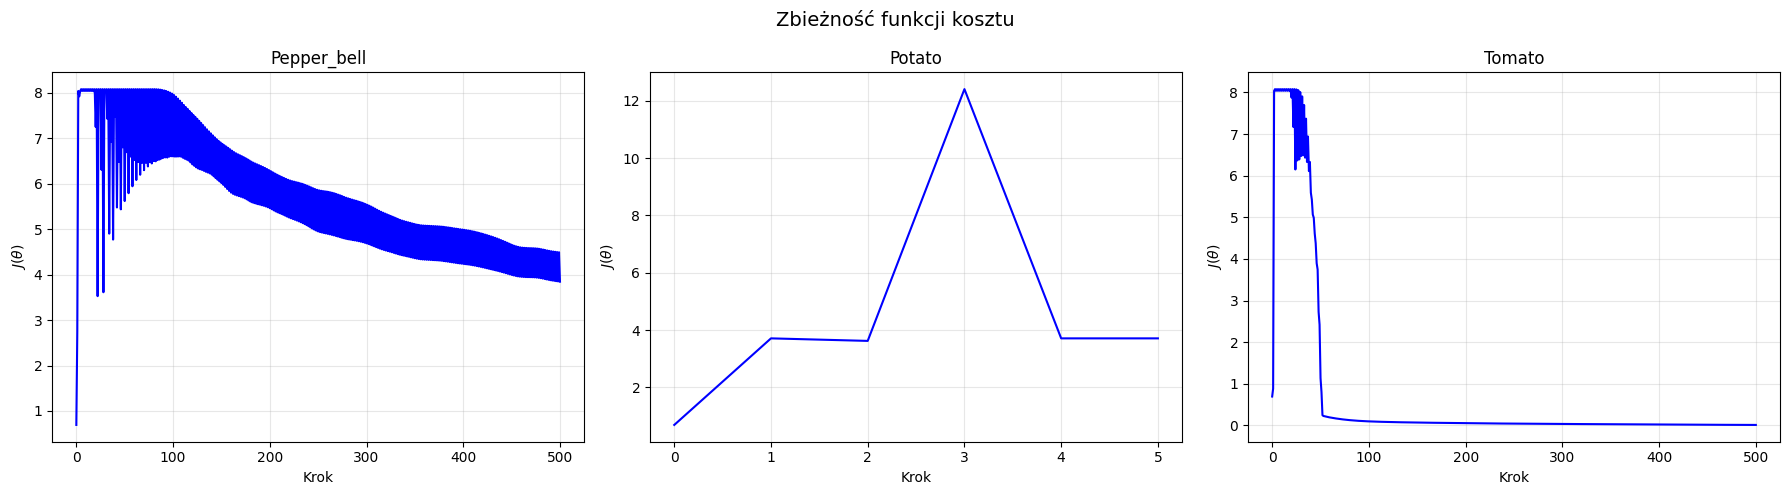

In [23]:
# Wykres zbieżności funkcji kosztu
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (pair_name, res) in enumerate(results.items()):
    axes[i].plot(res['costs'], color='blue', linewidth=1.5)
    axes[i].set_xlabel('Krok')
    axes[i].set_ylabel(r'$J(\theta)$')
    axes[i].set_title(pair_name.split(':')[0])
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Zbieżność funkcji kosztu', fontsize=14)
plt.tight_layout()
plt.show()

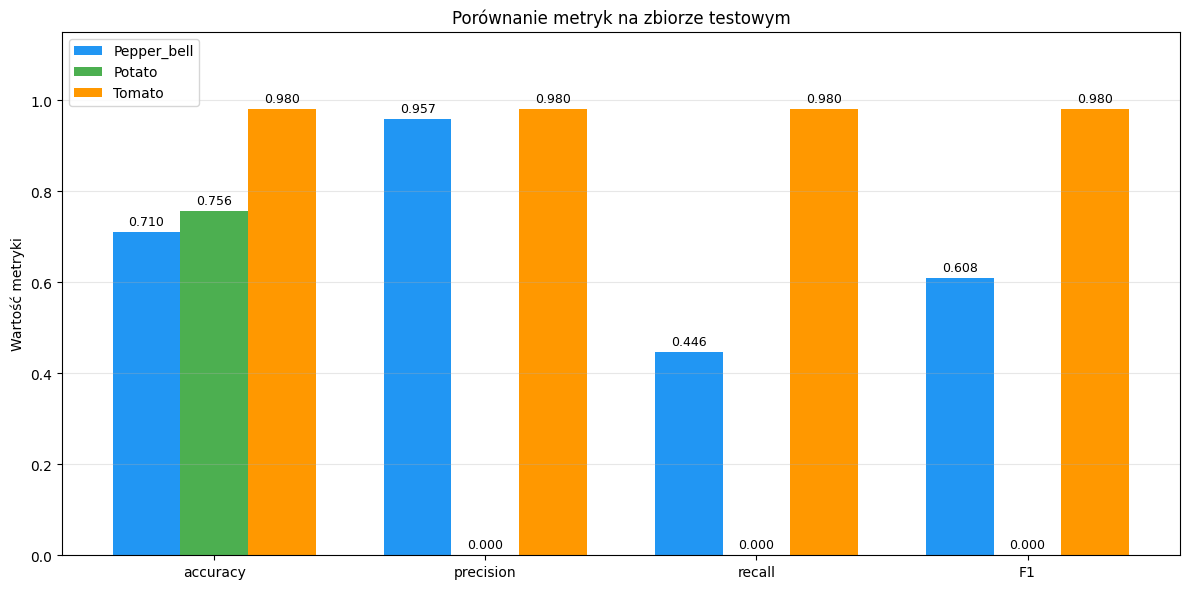

In [24]:
# Porównanie metryk na zbiorze testowym
metrics_names = ['accuracy', 'precision', 'recall', 'F1']
pair_names_list = list(results.keys())
short_names = [name.split(':')[0] for name in pair_names_list]

x_pos = np.arange(len(metrics_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, (pn, short) in enumerate(zip(pair_names_list, short_names)):
    vals = [results[pn]['test_metrics'][m] for m in metrics_names]
    bars = ax.bar(x_pos + i * width, vals, width, label=short, color=colors[i])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Wartość metryki')
ax.set_title('Porównanie metryk na zbiorze testowym')
ax.set_xticks(x_pos + width)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

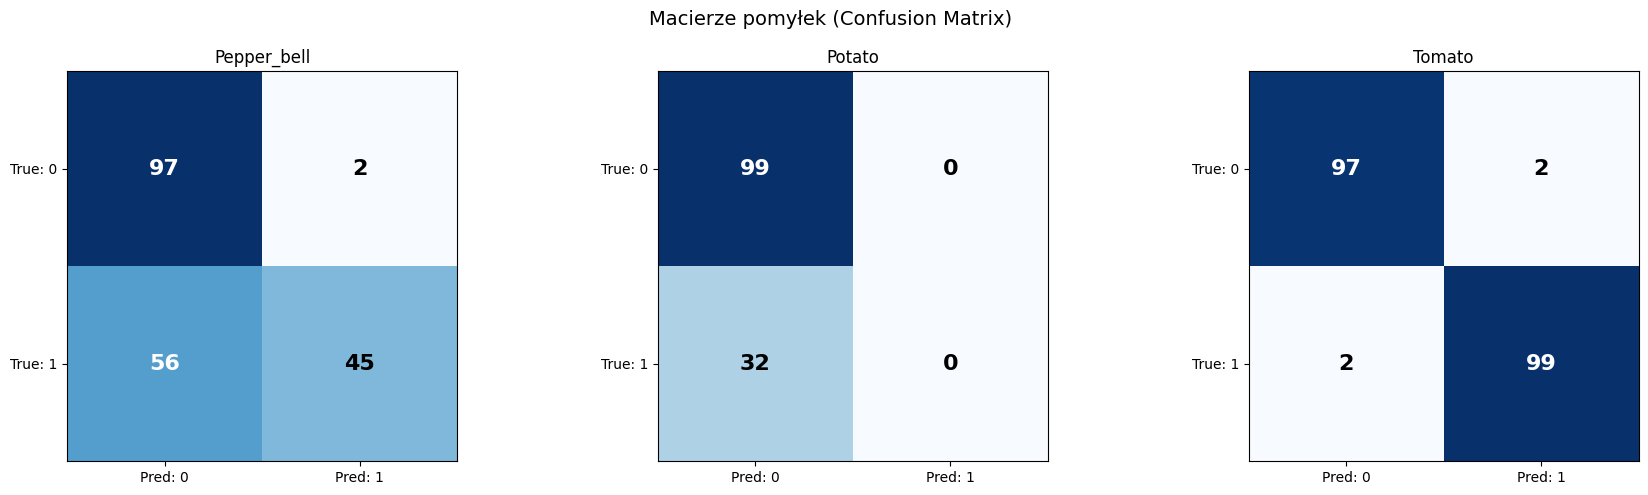

In [25]:
# Macierze pomyłek (Confusion Matrix)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (pair_name, res) in enumerate(results.items()):
    tm = res['test_metrics']
    cm = np.array([[tm['TN'], tm['FP']],
                    [tm['FN'], tm['TP']]])
    
    axes[i].imshow(cm, cmap='Blues', interpolation='nearest')
    axes[i].set_title(pair_name.split(':')[0])
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(['Pred: 0', 'Pred: 1'])
    axes[i].set_yticklabels(['True: 0', 'True: 1'])
    
    for r in range(2):
        for c in range(2):
            axes[i].text(c, r, str(cm[r, c]), ha='center', va='center',
                        fontsize=16, fontweight='bold',
                        color='white' if cm[r, c] > cm.max()/2 else 'black')

plt.suptitle('Macierze pomyłek (Confusion Matrix)', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Podsumowanie

Zestawienie wyników walidacji krzyżowej i ewaluacji na zbiorze testowym dla trzech par klas.
Wyniki powstają po zbalansowaniu klas oraz przy użyciu stratyfikowanego podziału danych.

In [26]:
# Tabela podsumowująca
print(f'{"Para klas":<45} | {"Zbiór":<6} | {"Accuracy":>8} | {"Precision":>9} | {"Recall":>6} | {"F1":>6}')
print('-' * 95)

for pair_name, res in results.items():
    short = pair_name.split(':')[0]
    cv = res['cv_metrics']
    tm = res['test_metrics']
    print(f'{short:<45} | {"CV":<6} | {cv["accuracy"]:>8.4f} | {cv["precision"]:>9.4f} | {cv["recall"]:>6.4f} | {cv["F1"]:>6.4f}')
    print(f'{"":<45} | {"Test":<6} | {tm["accuracy"]:>8.4f} | {tm["precision"]:>9.4f} | {tm["recall"]:>6.4f} | {tm["F1"]:>6.4f}')
    print('-' * 95)

Para klas                                     | Zbiór  | Accuracy | Precision | Recall |     F1
-----------------------------------------------------------------------------------------------
Pepper_bell                                   | CV     |   0.6500 |    0.8686 | 0.4984 | 0.5586
                                              | Test   |   0.7100 |    0.9574 | 0.4455 | 0.6081
-----------------------------------------------------------------------------------------------
Potato                                        | CV     |   0.7696 |    0.0000 | 0.0000 | 0.0000
                                              | Test   |   0.7557 |    0.0000 | 0.0000 | 0.0000
-----------------------------------------------------------------------------------------------
Tomato                                        | CV     |   0.9862 |    0.9906 | 0.9816 | 0.9860
                                              | Test   |   0.9800 |    0.9802 | 0.9802 | 0.9802
----------------------------------------